<a href="https://colab.research.google.com/github/natalipro12/MydataprogectsAPI/blob/main/Copy_of_Ttanslation_pttern_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Translation Quality Analysis

In [ ]:
import pandas as pd
import numpy as np

# 1. Create a fake dataset simulating translation quality data
np.random.seed(42)

n = 500
language_pairs = ['EN-FR', 'EN-DE', 'EN-ES', 'EN-JA', 'EN-AR', 'EN-PT']
ai_models = ['ModelA', 'ModelB', 'ModelC']
content_types = ['website', 'app', 'marketing', 'legal']

df = pd.DataFrame({
    'record_id': range(1, n+1),
    'language_pair': np.random.choice(language_pairs, n),
    'ai_model': np.random.choice(ai_models, n),
    'content_type': np.random.choice(content_types, n),
    'customer_id': np.random.randint(1000, 1050, n),
    'word_count': np.random.randint(20, 500, n),
    'edited': np.random.choice([0, 1], n, p=[0.65, 0.35]),  # 1 = user edited the translation
})

# 2.Make EN-JA more likely to be edited (simulate a real quality issue)
mask = df['language_pair'] == 'EN-JA'
df.loc[mask, 'edited'] = np.random.choice([0, 1], mask.sum(), p=[0.35, 0.65])



In [ ]:
df.head()

,record_id,language_pair,ai_model,content_type,customer_id,word_count,edited
0,1,EN-JA,ModelA,app,1033,339,0
1,2,EN-AR,ModelB,app,1043,300,1
2,3,EN-ES,ModelB,marketing,1034,299,0
3,4,EN-AR,ModelA,legal,1021,31,0
4,5,EN-AR,ModelC,legal,1043,293,0


In [ ]:
# 2. Edit rate by language pair
edit_rate_by_lang = df.groupby('language_pair')['edited'].mean().sort_values(ascending=False)
print(edit_rate_by_lang)

language_pair
EN-JA    0.618557
EN-ES    0.389610
EN-AR    0.346667
EN-FR    0.333333
EN-PT    0.325581
EN-DE    0.173333
Name: edited, dtype: float64



**most edited language_pair**
EN-JA    0.618557        



In [ ]:
# 3. Is it the language pair, or something else? Cross-check with content type
edit_rate_by_lang_content = df.groupby(['language_pair', 'content_type'])['edited'].mean().unstack()
print(edit_rate_by_lang_content)

content_type        app     legal  marketing   website
language_pair                                         
EN-AR          0.538462  0.312500   0.285714  0.320000
EN-DE          0.050000  0.133333   0.368421  0.142857
EN-ES          0.391304  0.521739   0.315789  0.250000
EN-FR          0.208333  0.400000   0.333333  0.411765
EN-JA          0.458333  0.652174   0.642857  0.727273
EN-PT          0.300000  0.200000   0.407407  0.333333


**in all  content types editing  for Ja remein elevated**

In [ ]:
# 4. Check AI model as a possible confound
edit_rate_by_model = df.groupby('ai_model')['edited'].mean().sort_values(ascending=False)
print(edit_rate_by_model)

ai_model
ModelB    0.415094
ModelA    0.396825
ModelC    0.302632
Name: edited, dtype: float64


In [ ]:
# 5. Sample size for  each Language pair
counts = df.groupby('language_pair').size()
print(counts)

language_pair
EN-AR    75
EN-DE    75
EN-ES    77
EN-FR    90
EN-JA    97
EN-PT    86
dtype: int64


In [ ]:
#  is EN-JA's sample size big enough to trust this number?
print(df[df['language_pair'] == 'EN-JA'].shape[0])

97


In [ ]:
# Is EN-JA's problem concentrated in one content type, or across the board?
print(edit_rate_by_lang_content.loc['EN-JA'])

content_type
app          0.458333
legal        0.652174
marketing    0.642857
website      0.727273
Name: EN-JA, dtype: float64


In [ ]:
# Is it one specific AI model underperforming on EN-JA specifically?
ja_by_model = df[df['language_pair'] == 'EN-JA'].groupby('ai_model')['edited'].mean()
print(ja_by_model)

ai_model
ModelA    0.621622
ModelB    0.700000
ModelC    0.450000
Name: edited, dtype: float64


**content type  distribution of edits**

website: 72.7% (highest)
legal: 65.2%
marketing: 64.3%
app: 45.8% (lowest, but still notably elevated vs. the overall 34% average)

   **distribution by AI model**

ModelB: 70.0% (worst)
ModelA: 62.2%
ModelC: 45.0% (best, but still elevated)

`The key insight :
EN-JA's high edit rate is not concentrated in one content type or one model. Every single content type is elevated, and every single model is elevated.

**Reasoning**
This pattern points toward something structural about the language pair itself — not a model bug, not a content-type-specific issue. Possible real-world hypotheses

Japanese may require more nuanced handling (honorifics, sentence structure, context-dependent grammar) that all current models struggle with similarly
Or: word count/complexity per sentence differs for Japanese and correlates with more editing
Or: EN-JA customers might just have stricter internal QA standards, inflating "edits" that aren't quality issues at all

In [ ]:
# Is it word count / complexity driving this, not the language itself?
print(df.groupby('language_pair')['word_count'].mean())

language_pair
EN-AR    261.453333
EN-DE    267.693333
EN-ES    266.285714
EN-FR    265.000000
EN-JA    261.484536
EN-PT    262.558140
Name: word_count, dtype: float64


**word count/complexity per sentence**
language pairs JA fit with average  (261-268 words ).

---

for EN-JA. This  against hypothesis  "Japanese content is just longer/more complex"

---



In [ ]:
#  is this dominated by a couple of customers?
print(df[df['language_pair']=='EN-JA'].groupby('customer_id')['edited'].mean().sort_values(ascending=False).head(10))

customer_id
1001    1.0
1003    1.0
1006    1.0
1004    1.0
1022    1.0
1020    1.0
1021    1.0
1017    1.0
1016    1.0
1013    1.0
Name: edited, dtype: float64


Customer breakdown: interesting, but likely misleading as shown.
Ten different customers all showing exactly 1.0 (100% edit rate) is a red flag — not of a real pattern, but of small sample size per customer. If a customer only has 1-2 EN-JA records total, a 100% rate just means "that one record happened to be edited," not "this customer always edits everything."

**add a count alongside the rate**

In [ ]:
# Add record counts so we don't get misled by customers with only 1-2 records
ja_customers = df[df['language_pair']=='EN-JA'].groupby('customer_id').agg(
    edit_rate=('edited', 'mean'),
    n_records=('edited', 'count')
).sort_values('edit_rate', ascending=False)

print(ja_customers.head(10))

             edit_rate  n_records
customer_id                      
1001               1.0          1
1003               1.0          1
1006               1.0          1
1004               1.0          2
1022               1.0          3
1020               1.0          1
1021               1.0          2
1017               1.0          2
1016               1.0          2
1013               1.0          2


Filter  customers   with 3+ entry .Assuming  that   common customer -nonprofeccional,  given number of entry 3+ will cut the noise bu can catch pattern

In [ ]:
# Filter to customers with at least 3 EN-JA records — reduces noise from one-off users
ja_customers_filtered = ja_customers[ja_customers['n_records'] >= 3].sort_values('edit_rate', ascending=False)
print(ja_customers_filtered)
print(f"\nCustomers remaining after filter: {len(ja_customers_filtered)} out of {len(ja_customers)}")

             edit_rate  n_records
customer_id                      
1022          1.000000          3
1039          1.000000          3
1044          0.750000          4
1046          0.666667          3
1048          0.666667          6
1025          0.666667          3
1024          0.666667          3
1000          0.666667          3
1009          0.500000          4
1034          0.500000          4
1033          0.400000          5
1011          0.400000          5
1010          0.333333          3
1036          0.000000          3

Customers remaining after filter: 14 out of 42


In [ ]:
# How much of the total EN-JA data does this filtered group represent?
coverage = ja_customers_filtered['n_records'].sum() / ja_customers['n_records'].sum()
print(f"Filtered customers represent {coverage:.1%} of all EN-JA records")

Filtered customers represent 53.6% of all EN-JA records


In [ ]:
# Display the filtered customer table with edit rates and record counts
print(ja_customers_filtered.to_string())

             edit_rate  n_records
customer_id                      
1022          1.000000          3
1039          1.000000          3
1044          0.750000          4
1046          0.666667          3
1048          0.666667          6
1025          0.666667          3
1024          0.666667          3
1000          0.666667          3
1009          0.500000          4
1034          0.500000          4
1033          0.400000          5
1011          0.400000          5
1010          0.333333          3
1036          0.000000          3


In [ ]:
# Cleaner formatted view  in  %
pd.set_option('display.float_format', '{:.2%}'.format)
print(ja_customers_filtered)
pd.reset_option('display.float_format')

             edit_rate  n_records
customer_id                      
1022           100.00%          3
1039           100.00%          3
1044            75.00%          4
1046            66.67%          3
1048            66.67%          6
1025            66.67%          3
1024            66.67%          3
1000            66.67%          3
1009            50.00%          4
1034            50.00%          4
1033            40.00%          5
1011            40.00%          5
1010            33.33%          3
1036             0.00%          3


In [ ]:
# Number of unique customers in the filtered table
print(len(ja_customers_filtered))

14


14 unique customers, covering 53% of all EN-JA records — that's a decent-sized group to draw a conclusion from, not just a couple of outliers.

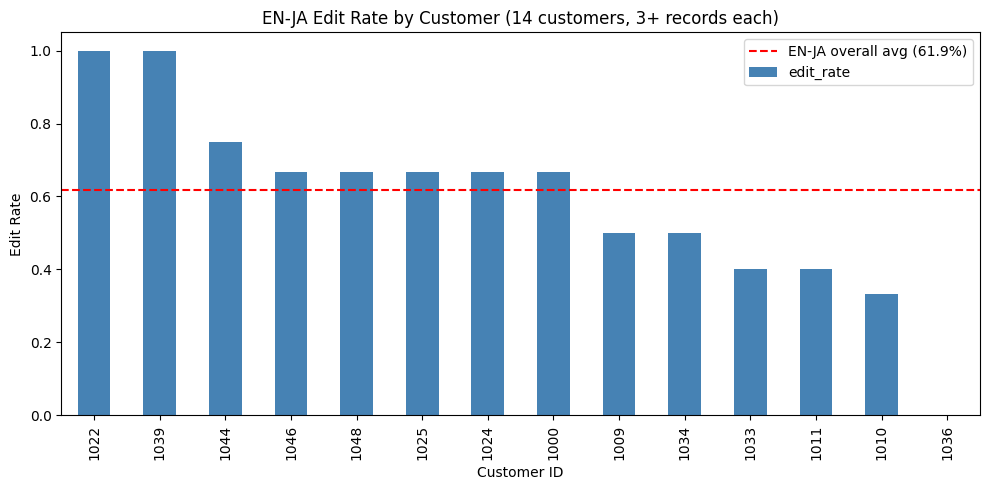

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ja_customers_filtered['edit_rate'].sort_values(ascending=False).plot(kind='bar', ax=ax, color='steelblue')

overall_ja_rate = df[df['language_pair']=='EN-JA']['edited'].mean()
ax.axhline(overall_ja_rate, color='red', linestyle='--', label=f'EN-JA overall avg ({overall_ja_rate:.1%})')

ax.set_title('EN-JA Edit Rate by Customer (14 customers, 3+ records each)')
ax.set_ylabel('Edit Rate')
ax.set_xlabel('Customer ID')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# How many of the 14 customers are close to the overall average vs way above/below it?
print(ja_customers_filtered['edit_rate'].describe())

count    14.000000
mean      0.586905
std       0.262156
min       0.000000
25%       0.425000
50%       0.666667
75%       0.666667
max       1.000000
Name: edit_rate, dtype: float64


range is huge: 0% to 100% — some customers never get edits, others always do
Std dev is large relative to the mean: 26.2% spread around a 58.7% average is substantial variation, not a tight cluster
Median (66.7%) sits noticeably above the mean (58.7%): this means there's a "long tail" pulling the average down — a few customers with low edit rates are dragging the mean below where most customers actually sit



1.   EN-JA does have a genuinely elevated edit rate overall
2.   ome customers are much more sensitive to Japanese translation quality
3.  the underlying translation quality issue is likely real,


# Investigation: Elevated Edit Rate for EN-JA Translations
1. **Finding**

EN-JA (English→Japanese) had a 61.9% edit rate — nearly double the overall average and 3x higher than the best pair, EN-DE (17.3%), across a sample of 97 records large enough to trust directionally.

2.** Hypotheses Tested and Ruled Out**
AI model: Elevated on all three models (45–70%) — not one bad model.
Content type: Elevated across every type (website, legal, marketing, app) — not one bad category.
Text complexity: Average word count for EN-JA (261) was in line with every other pair (261–268) — not a length/complexity effect.

Ruling these out pointed toward something more fundamental about the language pair or its users.

3. **Customer-Level Check**

Filtered to 14 customers with 3+ EN-JA records (53% of all EN-JA data) to avoid noise from one-off users. Edit rates ranged 0–100%, with a std dev of 26 points around a 59% mean — not tightly clustered. The median (66.7%) sat above the mean, showing a few low-edit customers pulling the average down while most customers actually cluster higher.

This rules out a purely uniform pattern but doesn't contradict the overall finding — it adds nuance.

4. **Conclusion**

EN-JA has a genuinely elevated edit rate, not explained by model, content type, or complexity — but the rate varies widely by customer even after filtering. Most likely: Japanese translation is inherently harder for current models (honorifics, context-dependent grammar), and customer-specific QA standards amplify that baseline unevenly.

5. **Recommended Next Steps**
Manually review EN-JA samples, especially from high-edit customers, to confirm real quality issues vs. stylistic preference.
Segment the 14 filtered customers by industry/content sensitivity to explain the spread better than customer ID alone.
If linguistic: flag for targeted model tuning or a Japanese-specific evaluation rubric.
If customer-driven: reframe as a QA/expectations issue, not a model problem.

In [ ]:
# 1. Split your ORIGINAL df into two pieces (same rows, different columns)
df_metadata = df[['record_id', 'language_pair', 'ai_model', 'content_type', 'customer_id', 'word_count']]
df_edit_data = df[['record_id', 'edited']]

In [ ]:
# 2. Push df_metadata into a real SQLite database
import sqlite3
conn = sqlite3.connect('translations.db')
df_metadata.to_sql('translations', conn, if_exists='replace', index=False)

500

In [ ]:
# 3. Save df_edit_data as a real CSV file
df_edit_data.to_csv('edits_export.csv', index=False)

In [ ]:
# 5. Merge  together   sql    and csv
df_final = df_sql.merge(df_edits, on='record_id', how='left')
print(df_final.shape)

(500, 7)


In [ ]:
# 6. Confirm it matches your ORIGINAL finding exactly
print(df_final.groupby('language_pair')['edited'].mean().sort_values(ascending=False))

language_pair
EN-JA    0.597403
EN-PT    0.493506
EN-AR    0.430380
EN-DE    0.347826
EN-ES    0.329268
EN-FR    0.279570
Name: edited, dtype: float64


In merged DF edits of    EN-JA    0.597403    close   to previous findings   60%   

In [ ]:
# Simulate an API response
# In real life this would be: requests.get("https://api.company.com/customers/1001")

import random
random.seed(3)

unique_customer_ids = df['customer_id'].unique()
industries = ['e-commerce', 'legal_services', 'gaming', 'saas', 'media']
plan_types = ['free', 'pro', 'enterprise']

def mock_api_call(customer_id):
    """Simulates a single API call returning customer metadata."""
    return {
        'customer_id': customer_id,
        'industry': random.choice(industries),
        'plan_type': random.choice(plan_types)
    }

# Simulate calling the API once per unique customer (like a real API loop would)
api_responses = [mock_api_call(cid) for cid in unique_customer_ids]

df_customers = pd.DataFrame(api_responses)
print(df_customers.shape)
df_customers.head()

(50, 3)


,customer_id,industry,plan_type
0,1033,legal_services,enterprise
1,1043,media,free
2,1034,gaming,enterprise
3,1021,saas,enterprise
4,1023,media,free


In [ ]:
# Merge the API data into  existing df_final (SQL + CSV combined)
df_full = df_final.merge(df_customers, on='customer_id', how='left')
print(df_full.shape)
df_full.head()

(500, 9)


,record_id,language_pair,ai_model,content_type,customer_id,word_count,edited,industry,plan_type
0,1,EN-JA,ModelA,marketing,1042,91,1,gaming,pro
1,2,EN-AR,ModelA,marketing,1018,234,1,gaming,free
2,3,EN-ES,ModelC,legal,1035,379,0,gaming,pro
3,4,EN-ES,ModelB,website,1001,363,1,e-commerce,enterprise
4,5,EN-JA,ModelB,app,1001,211,1,e-commerce,enterprise


Now   we can check  wich   indasry    with higer  edit  score

In [ ]:
# Which industry has the highest edit rate specifically for EN-JA?
ja_by_industry = df_full[df_full['language_pair']=='EN-JA'].groupby('industry').agg(
    edit_rate=('edited', 'mean'),
    n_records=('edited', 'count')
).sort_values('edit_rate', ascending=False)

print(ja_by_industry)

                edit_rate  n_records
industry                            
media            0.681818         22
saas             0.615385         13
legal_services   0.615385         13
e-commerce       0.571429         14
gaming           0.466667         15


In [ ]:
# Same check across ALL language pairs — is media always edited most, or just for EN-JA?
industry_overall = df_full.groupby('industry')['edited'].mean().sort_values(ascending=False)
print(industry_overall)

industry
e-commerce        0.453333
saas              0.428571
media             0.402597
legal_services    0.385417
gaming            0.357143
Name: edited, dtype: float64


In [ ]:
# Build a comparison table: overall edit rate vs EN-JA edit rate, by industry
overall_by_industry = df_full.groupby('industry')['edited'].mean()
ja_by_industry_only = df_full[df_full['language_pair']=='EN-JA'].groupby('industry')['edited'].mean()

comparison = pd.DataFrame({
    'overall_edit_rate': overall_by_industry,
    'ja_edit_rate': ja_by_industry_only
})

comparison['difference'] = comparison['ja_edit_rate'] - comparison['overall_edit_rate']
comparison = comparison.sort_values('difference', ascending=False)

print(comparison)

                overall_edit_rate  ja_edit_rate  difference
industry                                                   
media                    0.402597      0.681818    0.279221
legal_services           0.385417      0.615385    0.229968
saas                     0.428571      0.615385    0.186813
e-commerce               0.453333      0.571429    0.118095
gaming                   0.357143      0.466667    0.109524


**after testing model**, content type, word count, customer concentration, and now industry, none of them explain the EN-JA elevation. The most defensible conclusion is that the issue is inherent to Japanese translation quality itself , not any specific model, content category, or customer segment.